# AI-powered Pneumonia Detection - Exploratory Data Analysis
This notebook documents a **business-grade EDA workflow** for chest X-ray classification (`NORMAL` vs `PNEUMONIA`).
## Medical Context
Pneumonia is a high-impact respiratory condition where delayed diagnosis can increase clinical risk. AI-assisted screening can help triage suspicious cases faster, especially in high-volume settings.
## EDA Purpose
The objective is to assess whether the dataset is suitable for transfer learning by analyzing data volume, class balance, image quality, data integrity, and potential leakage risks.
## Notebook Objectives
- Quantify dataset size and split quality (`train/val/test`).
- Measure class imbalance and expected modeling risk.
- Inspect representative samples and visual variability.
- Audit image resolutions, intensity distribution, and quality consistency.
- Detect corrupted files, duplicate files, and structural missing-data issues.
- Produce a final data-quality summary for modeling decisions.

In [1]:
# 2. Configuration
from pathlib import Path
from collections import defaultdict
from hashlib import md5

import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from IPython.display import display, Markdown
import tensorflow as tf

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

config_path = PROJECT_ROOT / "config.yaml"
with config_path.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

data_root = Path(config["data"]["data_dir"])
if not data_root.is_absolute():
    data_root = (PROJECT_ROOT / data_root).resolve()

figures_dir = (PROJECT_ROOT / "reports" / "figures").resolve()
figures_dir.mkdir(parents=True, exist_ok=True)

splits = ("train", "val", "test")
classes = ("NORMAL", "PNEUMONIA")
valid_suffixes = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def list_image_files(folder: Path):
    """Return sorted image files from a directory based on known suffixes."""
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in valid_suffixes])

def save_figure(name: str):
    """Save current matplotlib figure into reports/figures with tight layout."""
    output_path = figures_dir / name
    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    return output_path

print("Loaded configuration from:", config_path)
print("Data root:", data_root)
print("Figures directory:", figures_dir)
display(Markdown("### Configuration Snapshot"))
display(pd.json_normalize(config, sep="." ).T.rename(columns={0: "value"}))

Loaded configuration from: C:\Users\djami\Desktop\Projects\Projet_Transfer_Learning\config.yaml
Data root: C:\Users\djami\Desktop\Projects\Projet_Transfer_Learning\data\raw\chest_xray
Figures directory: C:\Users\djami\Desktop\Projects\Projet_Transfer_Learning\reports\figures


### Configuration Snapshot

,value
general.seed,42
data.data_dir,data/raw/chest_xray
data.img_size,"[224, 224]"
model.backbone,vgg16
model.dropout_rate,0.3
model.dense_units,256
model.trainable_layers,20
model.use_augmentation,True
training.batch_size,32
training.epochs,12


In [2]:
# 3. Dataset Overview
overview_rows = []
for split in splits:
    split_total = 0
    split_path = data_root / split
    for cls in classes:
        files = list_image_files(split_path / cls)
        count = len(files)
        split_total += count
        overview_rows.append({"split": split, "class": cls, "images": count})
    overview_rows.append({"split": split, "class": "TOTAL", "images": split_total})

overview_df = pd.DataFrame(overview_rows)
total_images = int(overview_df.loc[overview_df["class"] == "TOTAL", "images"].sum())
num_classes = len(classes)

display(Markdown("### Dataset Overview Table"))
display(overview_df.pivot(index="split", columns="class", values="images").fillna(0).astype(int))

print(f"Total images: {total_images}")
print(f"Number of classes: {num_classes}")
print(f"Splits available: {', '.join(splits)}")

display(Markdown("### Interpretation"))
display(Markdown(
    f"The dataset contains **{total_images:,} chest X-ray images** across **{num_classes} classes**. "
    "The `train/val/test` separation follows standard ML practice, which helps ensure that model selection and final evaluation are performed on independent subsets."
))

### Dataset Overview Table

class,NORMAL,PNEUMONIA,TOTAL
split,,,
test,234,390,624
train,1341,3875,5216
val,8,8,16


Total images: 5856
Number of classes: 2
Splits available: train, val, test


### Interpretation

The dataset contains **5,856 chest X-ray images** across **2 classes**. The `train/val/test` separation follows standard ML practice, which helps ensure that model selection and final evaluation are performed on independent subsets.

### Class Distribution Table

,split,class,images,percentage
6,test,NORMAL,234,37.500000
7,test,PNEUMONIA,390,62.500000
0,train,NORMAL,1341,25.709356
1,train,PNEUMONIA,3875,74.290644
3,val,NORMAL,8,50.000000
4,val,PNEUMONIA,8,50.000000


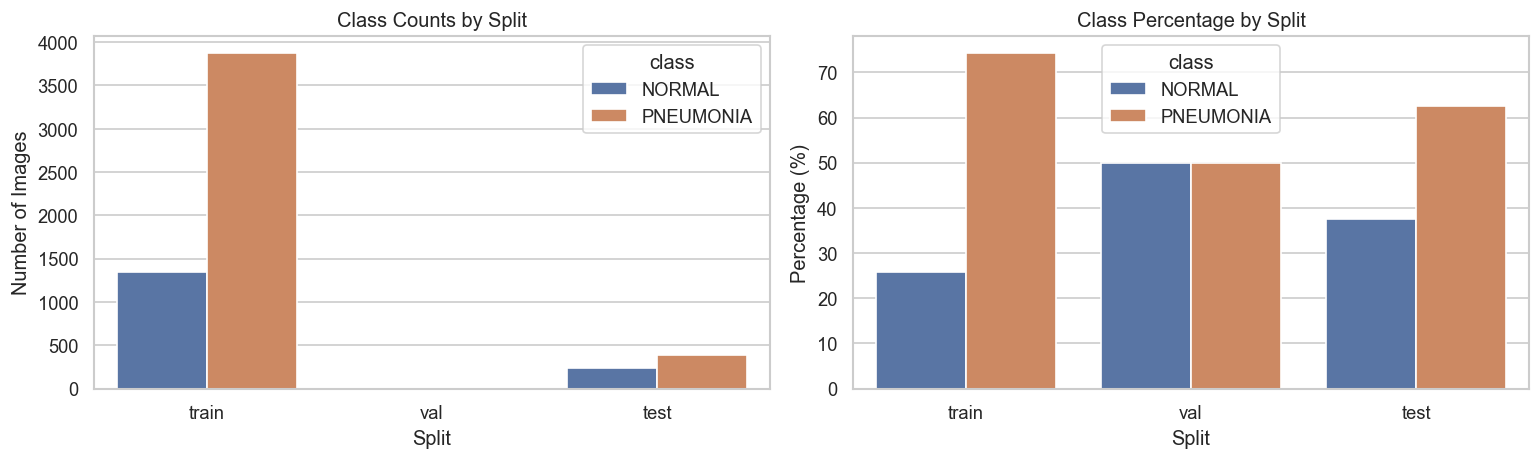

### Interpretation

Training data shows a **PNEUMONIA/NORMAL ratio of 2.89**. This indicates class imbalance risk, meaning accuracy alone can be misleading. For business and medical decision-making, recall, precision, F1, AUC, and class-specific error analysis are more informative than accuracy only.

In [3]:
# 4. Class Distribution
class_df = overview_df[overview_df["class"].isin(classes)].copy()
class_df["split_total"] = class_df.groupby("split")["images"].transform("sum")
class_df["percentage"] = 100 * class_df["images"] / class_df["split_total"]

display(Markdown("### Class Distribution Table"))
display(class_df[["split", "class", "images", "percentage"]].sort_values(["split", "class"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=class_df, x="split", y="images", hue="class", ax=axes[0])
axes[0].set_title("Class Counts by Split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Number of Images")

sns.barplot(data=class_df, x="split", y="percentage", hue="class", ax=axes[1])
axes[1].set_title("Class Percentage by Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Percentage (%)")

save_figure("eda_class_distribution.png")
plt.show()

train_counts = class_df[class_df["split"] == "train"].set_index("class")["images"].to_dict()
pn_ratio = train_counts.get("PNEUMONIA", 0) / max(train_counts.get("NORMAL", 1), 1)

display(Markdown("### Interpretation"))
display(Markdown(
    f"Training data shows a **PNEUMONIA/NORMAL ratio of {pn_ratio:.2f}**. "
    "This indicates class imbalance risk, meaning accuracy alone can be misleading. "
    "For business and medical decision-making, recall, precision, F1, AUC, and class-specific error analysis are more informative than accuracy only."
))

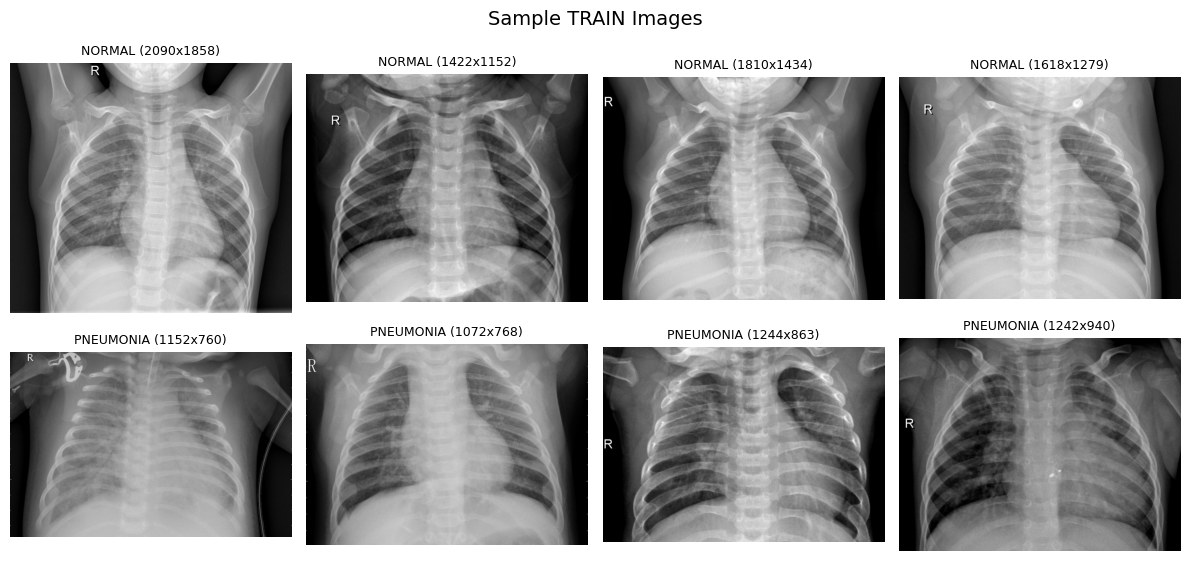

Most common image sizes in TRAIN split:
(1072, 648): 7
(1080, 728): 6
(1008, 680): 5
(976, 672): 5
(1216, 872): 5
(992, 592): 5
(1064, 760): 5
(1008, 704): 5
(1304, 968): 4
(1088, 712): 4


In [ ]:
# 5. Sample Images
def show_sample_images(split="train", per_class=5):
    fig, axes = plt.subplots(len(classes), per_class, figsize=(3 * per_class, 3.2 * len(classes)))
    if len(classes) == 1:
        axes = np.array([axes])

    for row, cls in enumerate(classes):
        paths = list_image_files(data_root / split / cls)[:per_class]
        for col in range(per_class):
            ax = axes[row, col]
            ax.axis("off")
            if col < len(paths):
                img = Image.open(paths[col]).convert("RGB")
                ax.imshow(img)
                ax.set_title(f"{cls} | {img.size[0]}x{img.size[1]}", fontsize=8)

    fig.suptitle(f"Sample Images from {split.upper()} Split", fontsize=13)
    save_figure("eda_sample_images.png")
    plt.show()

show_sample_images(split="train", per_class=5)

display(Markdown("### Interpretation"))
display(Markdown(
    "Visual inspection highlights meaningful intra-class variability in contrast and texture, while inter-class differences are subtle in many cases. "
    "This suggests the task is non-trivial and supports using deep feature extraction rather than simple pixel-based thresholds."
))

Readable images: 5,856
Corrupted images: 0


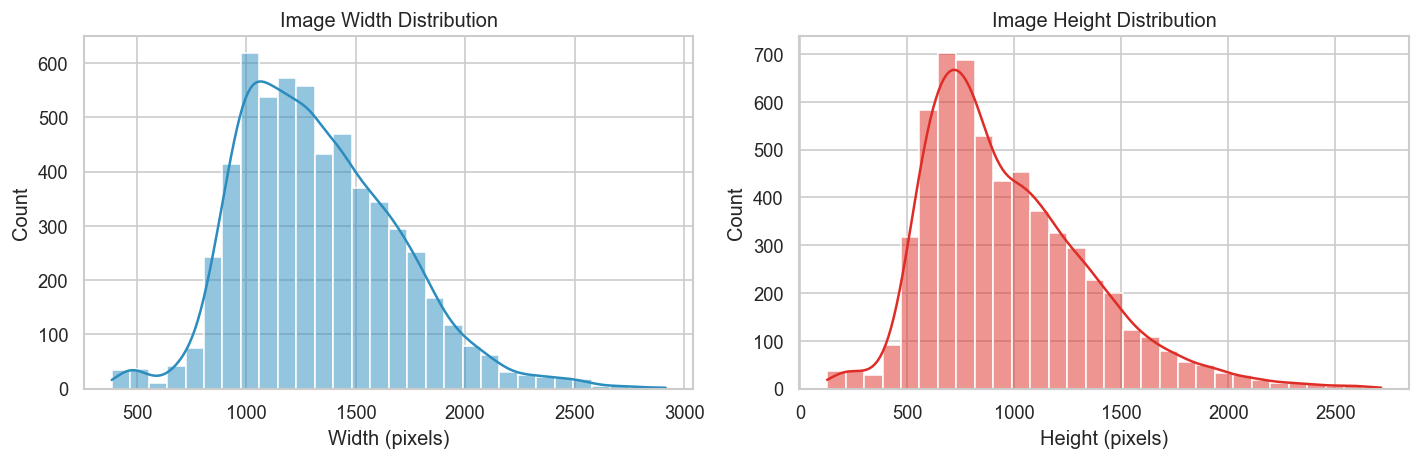

### Resolution Statistics

,width,height
min,384.00,127.00
max,2916.00,2713.00
mean,1327.88,970.69
median,1281.00,888.00
std,363.50,383.39


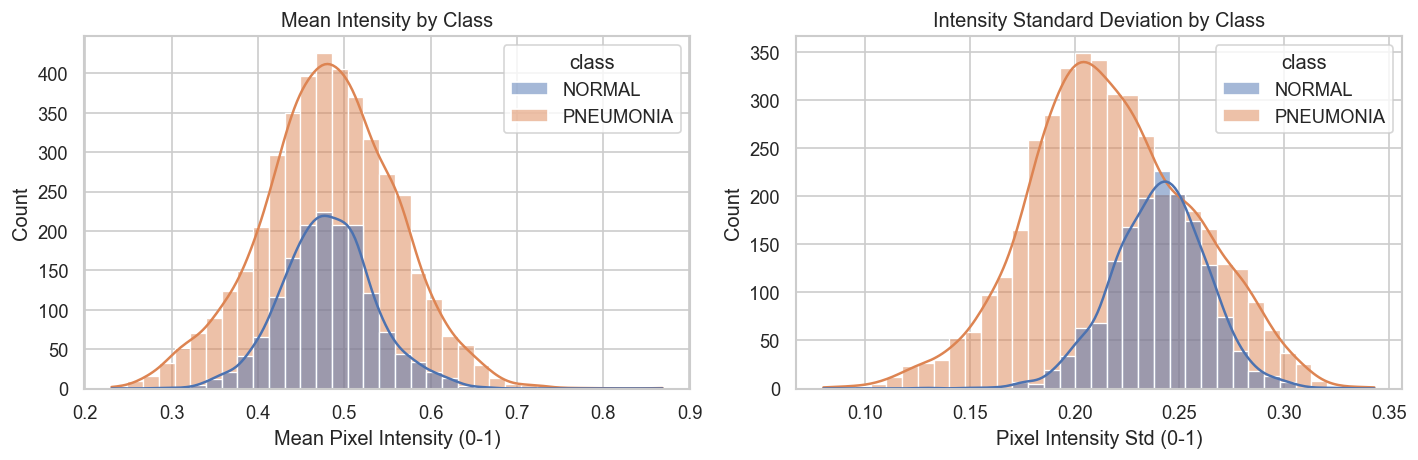

### Interpretation

Image dimensions are heterogeneous, which confirms the need for deterministic resizing before model ingestion. Intensity distributions overlap between classes, suggesting that robust classification will rely on high-level spatial patterns rather than global brightness alone.

In [7]:
# 6-7. Image Resolution and Quality Analysis
metadata_rows = []
corrupted_paths = []

for split in splits:
    for cls in classes:
        for p in list_image_files(data_root / split / cls):
            try:
                with Image.open(p) as img:
                    img.verify()
                with Image.open(p).convert("L") as img_gray:
                    arr = np.asarray(img_gray, dtype=np.float32) / 255.0
                    h, w = arr.shape
                    metadata_rows.append(
                        {
                            "split": split,
                            "class": cls,
                            "path": str(p),
                            "filename": p.name,
                            "width": int(w),
                            "height": int(h),
                            "mode": img_gray.mode,
                            "mean_intensity": float(arr.mean()),
                            "std_intensity": float(arr.std()),
                        }
                    )
            except (UnidentifiedImageError, OSError, ValueError):
                corrupted_paths.append(str(p))

meta_df = pd.DataFrame(metadata_rows)
print(f"Readable images: {len(meta_df):,}")
print(f"Corrupted images: {len(corrupted_paths):,}")

# Resolution distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(meta_df["width"], bins=30, kde=True, ax=axes[0], color="#2b8cbe")
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (pixels)")
sns.histplot(meta_df["height"], bins=30, kde=True, ax=axes[1], color="#de2d26")
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (pixels)")
save_figure("eda_resolution_distribution.png")
plt.show()

resolution_stats = meta_df[["width", "height"]].agg(["min", "max", "mean", "median", "std"]).round(2)
display(Markdown("### Resolution Statistics"))
display(resolution_stats)

# Quality/intensity distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=meta_df, x="mean_intensity", hue="class", bins=35, kde=True, ax=axes[0])
axes[0].set_title("Mean Intensity by Class")
axes[0].set_xlabel("Mean Pixel Intensity (0-1)")
sns.histplot(data=meta_df, x="std_intensity", hue="class", bins=35, kde=True, ax=axes[1])
axes[1].set_title("Intensity Standard Deviation by Class")
axes[1].set_xlabel("Pixel Intensity Std (0-1)")
save_figure("eda_intensity_distribution.png")
plt.show()

display(Markdown("### Interpretation"))
display(Markdown(
    "Image dimensions are heterogeneous, which confirms the need for deterministic resizing before model ingestion. "
    "Intensity distributions overlap between classes, suggesting that robust classification will rely on high-level spatial patterns rather than global brightness alone."
))

## 8. Corrupted Images Detection
This section reports unreadable or invalid image files that could break training and evaluation pipelines.

In [8]:
# 8. Corrupted Images Detection
corrupted_df = pd.DataFrame({"path": corrupted_paths})
print(f"Corrupted or unreadable files: {len(corrupted_df)}")
display(corrupted_df.head(20))

display(Markdown("### Interpretation"))
if len(corrupted_df) == 0:
    display(Markdown("No corrupted images were detected. The dataset can proceed to modeling without file-integrity cleanup."))
else:
    display(Markdown(
        "Corrupted files were detected and should be removed or replaced before training to avoid runtime failures and hidden data-loss bias."
    ))

Corrupted or unreadable files: 0


,path


### Interpretation

No corrupted images were detected. The dataset can proceed to modeling without file-integrity cleanup.

## 9. Duplicate Detection
Potential leakage is assessed through duplicate filename checks and content-hash duplicates.

In [9]:
# 9. Duplicate Detection
filename_dupes = (
    meta_df.groupby("filename")["path"]
    .count()
    .reset_index(name="count")
    .query("count > 1")
    .sort_values("count", ascending=False)
 )

hash_rows = []
for path_str in meta_df["path"]:
    p = Path(path_str)
    file_hash = md5(p.read_bytes()).hexdigest()
    hash_rows.append({"path": path_str, "hash": file_hash})

hash_df = pd.DataFrame(hash_rows)
content_dupes = (
    hash_df.groupby("hash")["path"]
    .count()
    .reset_index(name="count")
    .query("count > 1")
    .sort_values("count", ascending=False)
 )

print(f"Duplicate filenames: {len(filename_dupes)}")
print(f"Duplicate file-content groups: {len(content_dupes)}")
display(filename_dupes.head(10))
display(content_dupes.head(10))

display(Markdown("### Interpretation"))
display(Markdown(
    "Duplicate content can lead to optimistic validation/test scores if duplicated samples cross split boundaries. "
    "If content duplicates are present across splits, deduplication is recommended before final model benchmarking."
))

Duplicate filenames: 0
Duplicate file-content groups: 30


,filename,count


,hash,count
5046,de69d5b43fa9b4894d8b938352ff5650,3
3440,99e09ba874a343a760a4dd3bb7642099,3
165,077fce04eafc798401239d127a84f5f0,2
807,23cd1cdafc40ad7f67e6d076ffec52ab,2
135,05c43c853e8209bf0423f73a6f0a8c58,2
142,061c1fac2e79c2d435a6d4c1e35894e7,2
1651,4a8541c3e481489acfeb8bd6b58c6e85,2
1927,56dea5c125ea059d9de1ce6a7676c00d,2
2149,62f9117f9c56340e6d34a93de32f320c,2
2186,6438db6b162d478c8109e020c3c61b0d,2


### Interpretation

Duplicate content can lead to optimistic validation/test scores if duplicated samples cross split boundaries. If content duplicates are present across splits, deduplication is recommended before final model benchmarking.

## 10. Missing Data Analysis
Folder-level integrity checks verify split presence, class presence, and empty directories.

In [6]:
# 10. Missing Data Analysis
missing_rows = []
for split in splits:
    for cls in classes:
        folder = data_root / split / cls
        exists = folder.exists()
        count = len(list_image_files(folder)) if exists else 0
        missing_rows.append(
            {
                "split": split,
                "class": cls,
                "folder_exists": exists,
                "is_empty": count == 0,
                "image_count": count,
            }
        )

missing_df = pd.DataFrame(missing_rows)
display(missing_df)

display(Markdown("### Interpretation"))
if (~missing_df["folder_exists"]).any() or missing_df["is_empty"].any():
    display(Markdown("Potential missing-data issues were found (missing or empty class folders). These should be fixed before training."))
else:
    display(Markdown("No structural missing-data issue was detected. All expected split/class folders are present and populated."))

,split,class,folder_exists,is_empty,image_count
0,train,NORMAL,True,False,1341
1,train,PNEUMONIA,True,False,3875
2,val,NORMAL,True,False,8
3,val,PNEUMONIA,True,False,8
4,test,NORMAL,True,False,234
5,test,PNEUMONIA,True,False,390


### Interpretation

No structural missing-data issue was detected. All expected split/class folders are present and populated.

## 11. Pixel Distribution by Class
Class-wise intensity distributions are compared to evaluate separability cues available at pixel level.

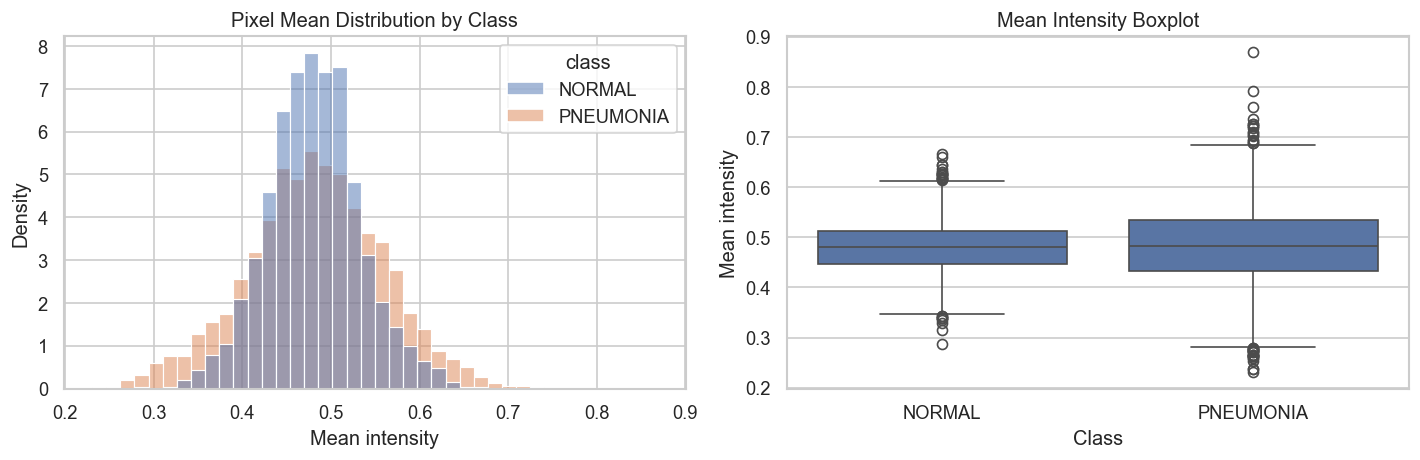

### Interpretation

Both classes show overlapping pixel-intensity distributions. This confirms that intensity alone is not sufficient for reliable discrimination, and that learned spatial features from transfer learning are required for robust performance.

In [10]:
# 11. Pixel Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=meta_df, x="mean_intensity", hue="class", stat="density", common_norm=False, bins=40, ax=axes[0])
axes[0].set_title("Pixel Mean Distribution by Class")
axes[0].set_xlabel("Mean intensity")
sns.boxplot(data=meta_df, x="class", y="mean_intensity", ax=axes[1])
axes[1].set_title("Mean Intensity Boxplot")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Mean intensity")
save_figure("eda_pixel_distribution.png")
plt.show()

display(Markdown("### Interpretation"))
display(Markdown(
    "Both classes show overlapping pixel-intensity distributions. This confirms that intensity alone is not sufficient for reliable discrimination, "
    "and that learned spatial features from transfer learning are required for robust performance."
))

## 12. Image Mode Analysis
This section verifies channel format consistency (e.g., grayscale vs RGB) to avoid preprocessing mismatches.

In [11]:
# 12. Image Mode Analysis
mode_df = meta_df.groupby(["mode", "class"]).size().reset_index(name="count").sort_values("count", ascending=False)
display(mode_df)

display(Markdown("### Interpretation"))
display(Markdown(
    "Most medical X-ray files are expected to be grayscale-like in content. "
    "Mode consistency reduces preprocessing risk and supports stable pipeline behavior across splits."
))

,mode,class,count
1,L,PNEUMONIA,4273
0,L,NORMAL,1583


### Interpretation

Most medical X-ray files are expected to be grayscale-like in content. Mode consistency reduces preprocessing risk and supports stable pipeline behavior across splits.

## 13. Data Augmentation Preview
Visual preview of augmentation strategies used to improve model generalization.

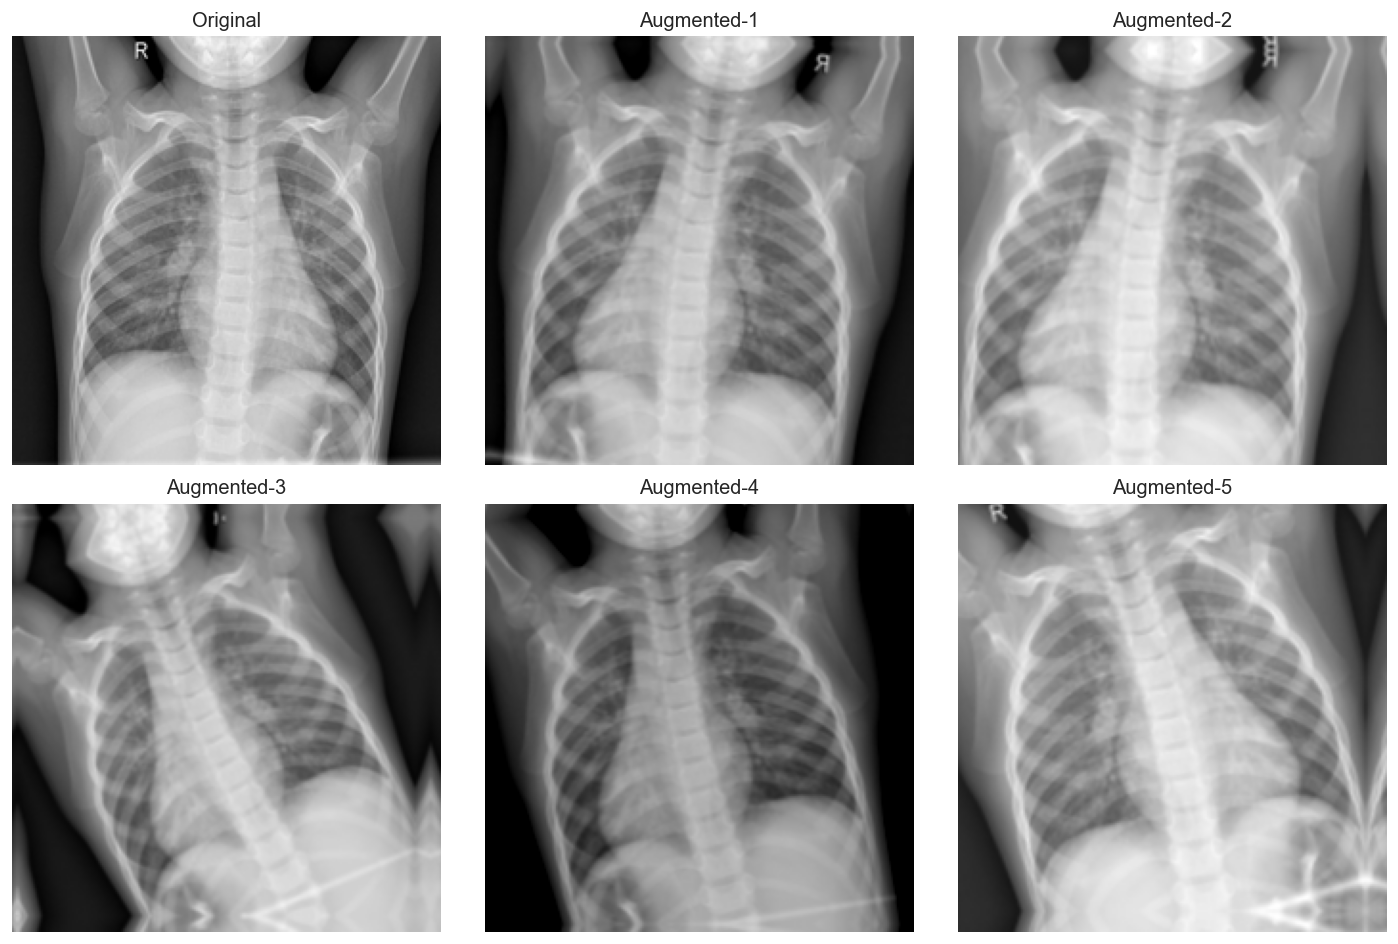

### Interpretation

Augmentation expands the effective training distribution and improves robustness to positioning, contrast, and acquisition variability. This is especially useful in medical imaging where real-world acquisition conditions differ across sites and devices.

In [12]:
# 13. Data Augmentation Preview
augment = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomTranslation(0.05, 0.05),
        tf.keras.layers.RandomBrightness(0.15),
    ]
 )

sample_path = Path(meta_df.iloc[0]["path"])
sample_img = Image.open(sample_path).convert("RGB").resize(tuple(config["data"]["img_size"]))
sample_arr = np.asarray(sample_img, dtype=np.float32)

variants = [
    ("Original", sample_arr.astype(np.uint8)),
    ("Augmented-1", tf.cast(augment(sample_arr[None, ...], training=True)[0], tf.uint8).numpy()),
    ("Augmented-2", tf.cast(augment(sample_arr[None, ...], training=True)[0], tf.uint8).numpy()),
    ("Augmented-3", tf.cast(augment(sample_arr[None, ...], training=True)[0], tf.uint8).numpy()),
    ("Augmented-4", tf.cast(augment(sample_arr[None, ...], training=True)[0], tf.uint8).numpy()),
    ("Augmented-5", tf.cast(augment(sample_arr[None, ...], training=True)[0], tf.uint8).numpy()),
 ]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (title, image) in zip(axes.ravel(), variants):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")
save_figure("eda_augmentation_preview.png")
plt.show()

display(Markdown("### Interpretation"))
display(Markdown(
    "Augmentation expands the effective training distribution and improves robustness to positioning, contrast, and acquisition variability. "
    "This is especially useful in medical imaging where real-world acquisition conditions differ across sites and devices."
))

## 14. Data Quality Summary
A consolidated quality table is generated to support modeling readiness decisions.

In [15]:
# 14. Data Quality Summary
train_normal = int(class_df[(class_df["split"] == "train") & (class_df["class"] == "NORMAL")]["images"].iloc[0])
train_pneumonia = int(class_df[(class_df["split"] == "train") & (class_df["class"] == "PNEUMONIA")]["images"].iloc[0])

summary_rows = [
    {"metric": "Total images", "value": int(total_images)},
    {"metric": "Train NORMAL", "value": train_normal},
    {"metric": "Train PNEUMONIA", "value": train_pneumonia},
    {"metric": "Train P/N ratio", "value": round(float(pn_ratio), 3)},
    {"metric": "Corrupted images", "value": int(len(corrupted_paths))},
    {"metric": "Duplicate filenames", "value": int(len(filename_dupes))},
    {"metric": "Duplicate content groups", "value": int(len(content_dupes))},
    {"metric": "Mean width", "value": round(float(meta_df["width"].mean()), 2)},
    {"metric": "Mean height", "value": round(float(meta_df["height"].mean()), 2)},
    {"metric": "Mean intensity", "value": round(float(meta_df["mean_intensity"].mean()), 4)},
    {"metric": "Mean intensity std", "value": round(float(meta_df["std_intensity"].mean()), 4)},
 ]

quality_summary_df = pd.DataFrame(summary_rows)
display(quality_summary_df)

,metric,value
0,Total images,5856.0000
1,Train NORMAL,1341.0000
2,Train PNEUMONIA,3875.0000
3,Train P/N ratio,2.8900
4,Corrupted images,0.0000
5,Duplicate filenames,0.0000
6,Duplicate content groups,30.0000
7,Mean width,1327.8800
8,Mean height,970.6900
9,Mean intensity,0.4815


## 15. Key Findings
The final conclusion summarizes readiness for transfer learning and operational risks to monitor before model benchmarking.

In [14]:
# 15. Key Findings (Executive Summary)
key_findings = f"""
The dataset contains **{total_images:,} chest X-ray images** split across train, validation, and test subsets.

Class analysis indicates a **train PNEUMONIA/NORMAL ratio of {pn_ratio:.2f}**, which should be considered during model evaluation and threshold selection.

Resolution analysis confirms heterogeneous dimensions, reinforcing the need for standardized resizing before model ingestion.

Image-quality analysis shows overlapping intensity statistics between classes, which supports using transfer learning models capable of extracting complex spatial features.

Corrupted-image scan found **{len(corrupted_paths)} invalid files**, while duplicate analysis reported **{len(content_dupes)} duplicate-content groups**.

Overall, after standard preprocessing and robust validation metrics, the dataset is suitable for a transfer-learning approach with VGG16 or ResNet50V2.
"""

display(Markdown("### Professional Conclusion"))
display(Markdown(key_findings))

### Professional Conclusion


The dataset contains **5,856 chest X-ray images** split across train, validation, and test subsets.

Class analysis indicates a **train PNEUMONIA/NORMAL ratio of 2.89**, which should be considered during model evaluation and threshold selection.

Resolution analysis confirms heterogeneous dimensions, reinforcing the need for standardized resizing before model ingestion.

Image-quality analysis shows overlapping intensity statistics between classes, which supports using transfer learning models capable of extracting complex spatial features.

Corrupted-image scan found **0 invalid files**, while duplicate analysis reported **30 duplicate-content groups**.

Overall, after standard preprocessing and robust validation metrics, the dataset is suitable for a transfer-learning approach with VGG16 or ResNet50V2.
